# Coherent Phonon Graphs

**Import Libraries**

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import numpy as np

**Download Files**

In [44]:

col_names = ['Position(mm)', 'Voltage(V)', 'Phase(Theta)'] # Define column names for our .txt files

metal = "bismuth" # Choose metal (bismuth or antimony)

files = glob.glob(f"{metal}/data/*.txt") # Download files
files = sorted(files) # Sort files

**Define Constants**

In [45]:
# speed of light
c = 299792458

# Reflectivity (Delta V)
delta_v = -1
if metal == "bismuth":
    delta_v = 80.15e-3
if metal == "antimony":
    delta_v = 1

# trial length (bismuth: 81, antimony: 161)
trial_len = -1 
if metal == "bismuth":
    trial_len = 81
if metal == "antimony":
    trial_len = 161

**Average Trials and Plot Data**

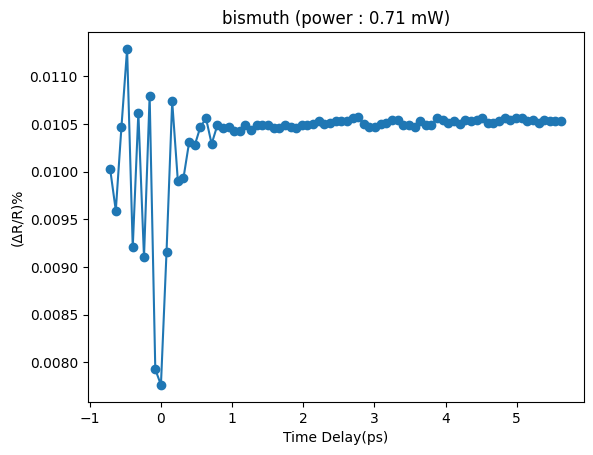

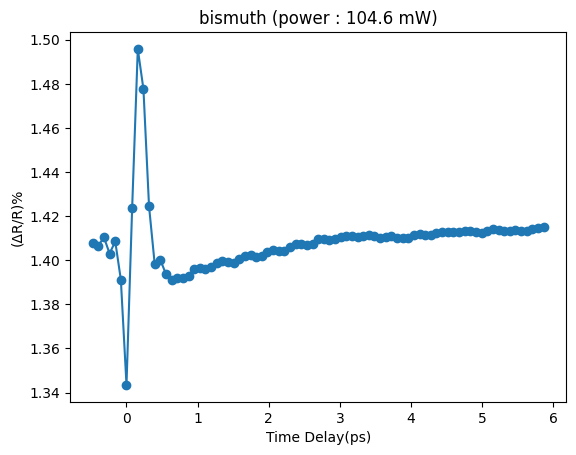

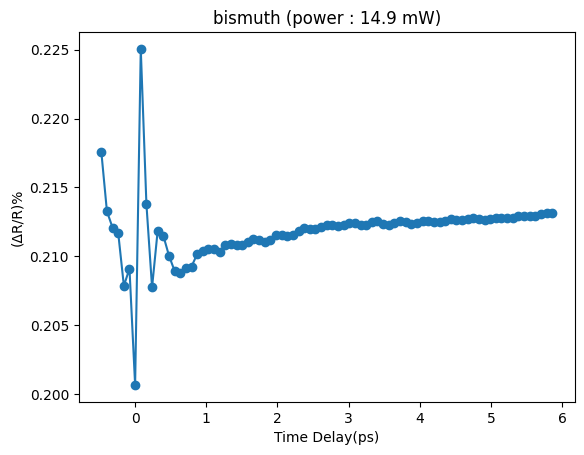

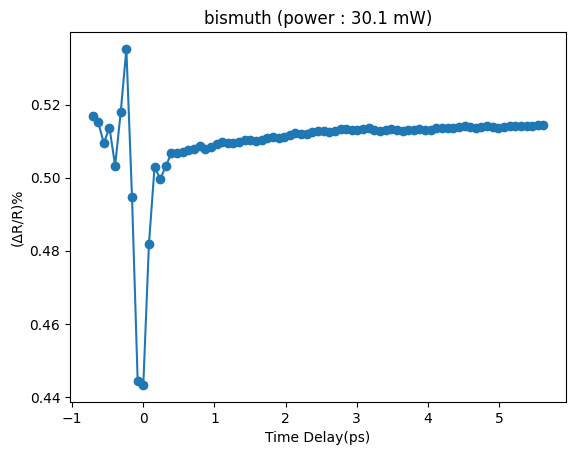

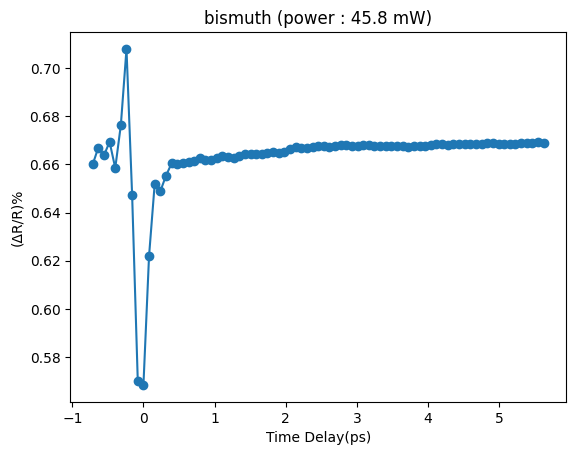

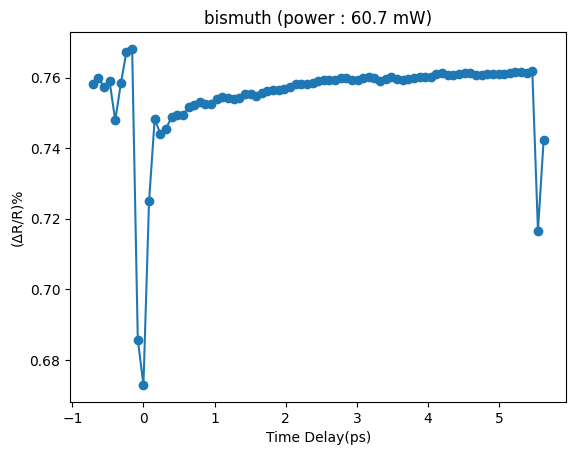

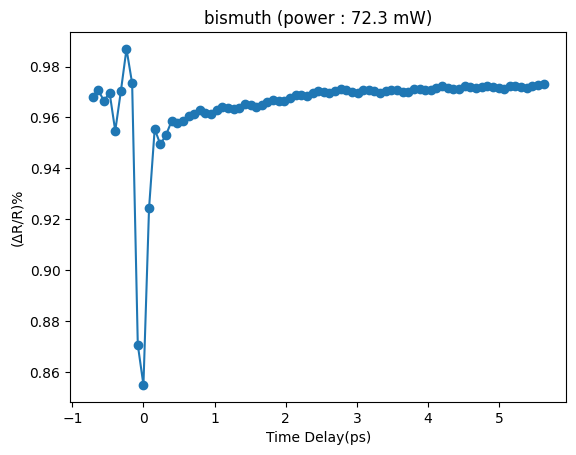

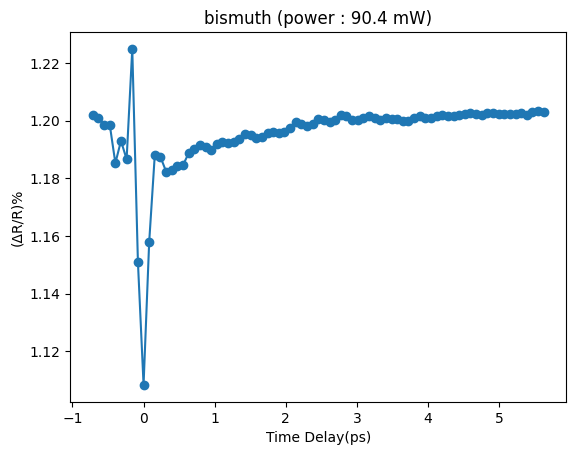

In [48]:
for file in files:
    df = pd.read_csv(file, sep=r"\s+", header=None, names=col_names)
    position = df["Position(mm)"]
    voltage = df["Voltage(V)"] 
    time = 2 * (position / 10**3) / c

    # Convert time from seconds to picoseconds (10^-12)
    time = time * 10**12
    average_voltage = voltage.groupby(voltage.index % trial_len).mean().reset_index(drop=True)
    time_trunc = time[ : trial_len]

    t0_idx = np.argmin(average_voltage)
    t0 = time_trunc[t0_idx]
    time_trunc -= t0

    # normalize voltage
    R_perc = (average_voltage / delta_v) * 100

    # find pump power
    f = file.rsplit('.', 1)[0]
    power = f.rsplit('/', 1)[1]

    plt.figure()
    plt.plot(time_trunc, R_perc)
    plt.scatter(time_trunc, R_perc)
    plt.xlabel("Time Delay(ps)")
    plt.ylabel(f"(\u0394R/R)%")
    plt.title(f"{metal} (power : {power} mW)")

    # plt.savefig(f"{metal}_{power}.pdf")
    plt.show()